# Zadanie 5
## Klasyfikacja Metabolizm/Ekstrakcja/Toksyczność

| Task | Category |
|------|-------------|
|cyp2d6_veith| Metabolism |
|cyp3a4_veith| Metabolism |
|hERG_Karim| Extraction |
|pgp_broccatelli| Toxicity |


In [9]:
import pandas as pd
from os import getcwd
import seaborn as sns
import matplotlib.pyplot as plt
import random_forest_model
# print(getcwd())

df = pd.read_parquet('./../../../dataset.parquet')
tasks = ['cyp2d6_veith', 'cyp3a4_veith', 'hERG_Karim', 'pgp_broccatelli']
df = df[df['task'].isin(tasks)]
df_wide = df.pivot_table(index='smiles', columns='task', values='label')

In [10]:
print(df['task'].value_counts())
avg_tasks = df.groupby('smiles')['task'].nunique().mean()
print(f"Średnia liczba zadań na smiles: {avg_tasks:.2f}")
presence_mask = df_wide.notna().astype(int)

overlap_matrix = presence_mask.T @ presence_mask

stats_df = df.groupby('task')['label'].agg(['mean', 'count', 'std']).reset_index()
overlap_matrix = overlap_matrix.merge(stats_df, on='task')
overlap_matrix.head()

task
hERG_Karim         13445
cyp2d6_veith       13130
cyp3a4_veith       12328
pgp_broccatelli     1218
Name: count, dtype: int64
Średnia liczba zadań na smiles: 1.34


,task,cyp2d6_veith,cyp3a4_veith,hERG_Karim,pgp_broccatelli,mean,count,std
0,cyp2d6_veith,13130,9932,71,137,0.191470,13130,0.393473
1,cyp3a4_veith,9932,12328,61,134,0.414504,12328,0.492656
2,hERG_Karim,71,61,13445,55,0.499665,13445,0.500018
3,pgp_broccatelli,137,134,55,1212,0.533662,1218,0.499071


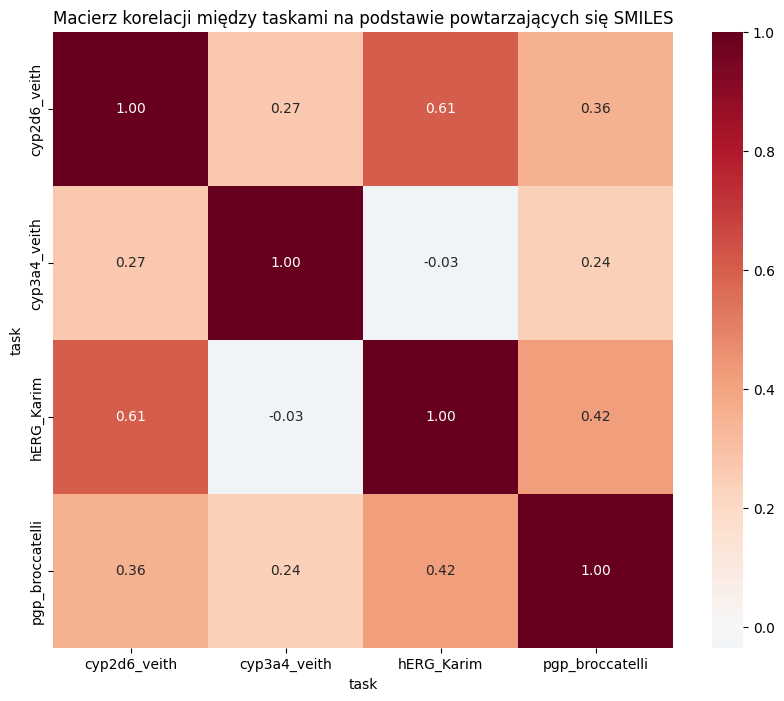

In [11]:
mask = df.groupby('smiles')['task'].transform('nunique') > 1
duplicated_rows = df[df.groupby('smiles')['task'].transform('nunique') > 1].sort_values('smiles')
corr_matrix = df_wide.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Macierz korelacji między taskami na podstawie powtarzających się SMILES')
plt.show()

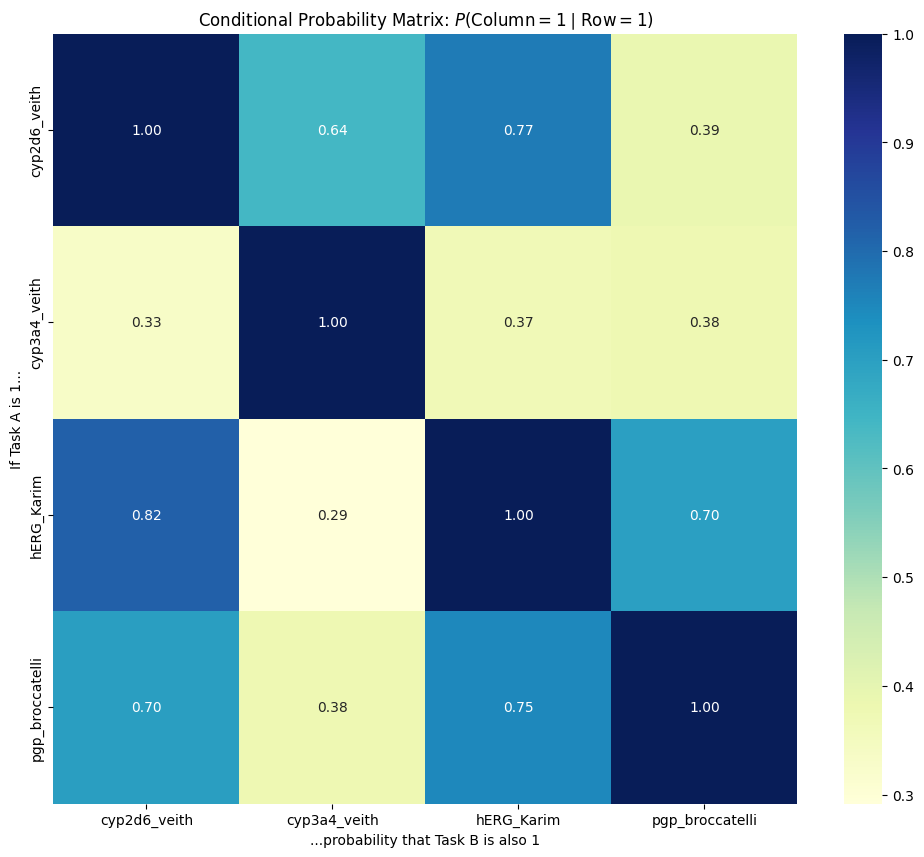

In [12]:
ones_mask = (df_wide == 1).astype(int)
intersection_11 = ones_mask.T @ ones_mask

valid_mask = df_wide.notna().astype(int)
intersection_1x = ones_mask.T @ valid_mask

cond_prob = intersection_11 / intersection_1x

plt.figure(figsize=(12, 10))
sns.heatmap(cond_prob, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Conditional Probability Matrix: $P(\\text{Column}=1 \\mid \\text{Row}=1)$")
plt.ylabel("If Task A is 1...")
plt.xlabel("...probability that Task B is also 1")
plt.show()

### Eksperyment random forest dla 20 najważniejszych wg gemini cech oraz morgan finterprint

Użyte kolumny są w pliku random_forest_model.py

In [13]:
summary_df = random_forest_model.run_single_task_pipeline(df, tasks)
summary_df['SOTA acc'] = ['0.790±0.001', '0.916±0.000', ' 0.880±0.002', '0.938±0.002']
summary_df


--- Top 15 najważniejszych cech dla cyp2d6_veith ---
            feature  importance
   MaxPartialCharge    0.029700
               TPSA    0.028883
           BalabanJ    0.023421
            MolLogP    0.021378
              MolMR    0.017278
          LabuteASA    0.014830
              MolWt    0.014190
            NOCount    0.014145
                qed    0.014012
MaxAbsPartialCharge    0.013871
       FractionCSP3    0.012751
            bit_650    0.012679
NumValenceElectrons    0.012522
     HeavyAtomCount    0.010742
  NumRotatableBonds    0.010537

--- Top 15 najważniejszych cech dla cyp3a4_veith ---
            feature  importance
            MolLogP    0.039854
              MolMR    0.036897
          LabuteASA    0.028927
              MolWt    0.023118
           BalabanJ    0.021894
     HeavyAtomCount    0.020861
NumValenceElectrons    0.019438
       FractionCSP3    0.019200
   MaxPartialCharge    0.017923
   NumAromaticRings    0.017027
          RingCount    0.014

,task,auc,acc,f1,SOTA acc
0,cyp2d6_veith,0.873928,0.872430,0.537931,0.790±0.001
1,cyp3a4_veith,0.885595,0.797242,0.740933,0.916±0.000
2,hERG_Karim,0.926931,0.851990,0.852264,0.880±0.002
3,pgp_broccatelli,0.932104,0.868852,0.866667,0.938±0.002


### Random forest dla wszystkich kolumn które nie są wtórnie wyliczone

Wybrany przez gemini maksymalnie duży zbiór cech, unikając redundancji oraz wartości które zostaną obliczone przez morgan fingerprint.

In [14]:
# primary_experimental_feats = [
#     # --- Kwantowe (Gems!) ---
#     'dipole', 'homo_lumo', 'energy',
#
#     # --- Fizykochemiczne podstawy ---
#     'qed', 'MolWt', 'TPSA', 'MolLogP', 'MolMR', 'FractionCSP3',
#
#     # --- Ładunki i Reaktywność ---
#     'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge',
#
#     # --- Liczniki (H-Bonds & Size) ---
#     'NumHAcceptors', 'NumHDonors', 'NumRotatableBonds', 'HeavyAtomCount', 'NumValenceElectrons',
#
#     # --- Architektura Pierścieni ---
#     'NumAromaticRings', 'NumSaturatedRings', 'RingCount',
#
#     # --- Fragmenty specyficzne (Najważniejsze grupy funkcyjne) ---
#     'fr_Al_OH', 'fr_Ar_OH', 'fr_Ar_N', 'fr_Ar_NH', 'fr_COO', 'fr_C_O', 'fr_NH0', 'fr_NH1', 'fr_NH2',
#     'fr_benzene', 'fr_ester', 'fr_ether', 'fr_halogen', 'fr_ketone', 'fr_nitro', 'fr_phenol',
#     'fr_piperdine', 'fr_pyridine', 'fr_sulfonamd', 'fr_urea'
# ]
#
# summary_df = random_forest_model.run_single_task_pipeline(df, tasks, features=primary_experimental_feats, n_estimators=500)
# summary_df['SOTA acc'] = ['0.790±0.001', '0.916±0.000', ' 0.880±0.002', '0.938±0.002']
# summary_df


--- Top 15 najważniejszych cech dla cyp2d6_veith ---
            feature  importance
MinAbsPartialCharge    0.025427
               TPSA    0.024732
   MaxPartialCharge    0.024708
            MolLogP    0.021300
              MolMR    0.016570
             energy    0.016033
              MolWt    0.013694
          homo_lumo    0.013482
                qed    0.013136
   MinPartialCharge    0.013014
            bit_650    0.012296
       FractionCSP3    0.012264
MaxAbsPartialCharge    0.012093
NumValenceElectrons    0.012022
             dipole    0.011952

--- Top 15 najważniejszych cech dla cyp3a4_veith ---
            feature  importance
            MolLogP    0.037636
              MolMR    0.034503
              MolWt    0.025264
NumValenceElectrons    0.023081
   NumAromaticRings    0.020910
     HeavyAtomCount    0.020539
       FractionCSP3    0.017632
          homo_lumo    0.015663
          RingCount    0.015618
  NumRotatableBonds    0.015607
MinAbsPartialCharge    0.014

,task,auc,acc,f1,SOTA acc
0,cyp2d6_veith,0.878271,0.870145,0.527046,0.790±0.001
1,cyp3a4_veith,0.888830,0.802109,0.747673,0.916±0.000
2,hERG_Karim,0.928506,0.852361,0.852581,0.880±0.002
3,pgp_broccatelli,0.935766,0.872951,0.870293,0.938±0.002


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Start treningu na cuda. Ilość cech: 1066, Ilość zadań: 4
Epoch 00 | Train Loss: 0.4799 | Val Loss: 0.4342 | Avg Val AUC: 0.8744
Epoch 01 | Train Loss: 0.3857 | Val Loss: 0.4064 | Avg Val AUC: 0.8929
Epoch 02 | Train Loss: 0.3430 | Val Loss: 0.3871 | Avg Val AUC: 0.8976
Epoch 03 | Train Loss: 0.3075 | Val Loss: 0.3869 | Avg Val AUC: 0.9025
Epoch 04 | Train Loss: 0.2751 | Val Loss: 0.3982 | Avg Val AUC: 0.9026
Epoch 05 | Train Loss: 0.2468 | Val Loss: 0.4037 | Avg Val AUC: 0.9041
Epoch 06 | Train Loss: 0.2207 | Val Loss: 0.4023 | Avg Val AUC: 0.9041
Epoch 07 | Train Loss: 0.1972 | Val Loss: 0.4190 | Avg Val AUC: 0.9076
Epoch 08 | Train Loss: 0.1754 | Val Loss: 0.4379 | Avg Val AUC: 0.9048
Epoch 09 | Train Loss: 0.1581 | Val Loss: 0.4490 | Avg Val AUC: 0.9038
Epoch 10 | Train Loss: 0.1510 | Val Loss: 0.4582 | Avg Val AUC: 0.9066
Epoch 11 | Train Loss: 0.1392 | Val Loss: 0.4664 | Avg Val AUC: 0.9082
Epo

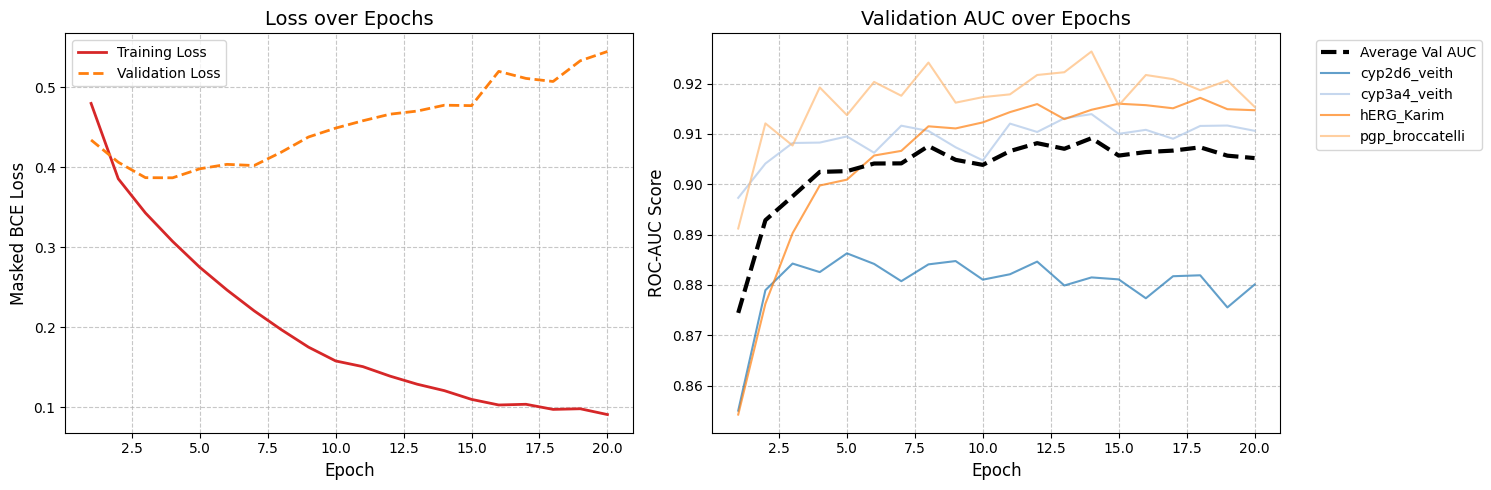


--- FINAL TEST AUC ---
cyp2d6_veith: 0.8688
cyp3a4_veith: 0.9049
hERG_Karim: 0.9158
pgp_broccatelli: 0.9242

--- FEATURE IMPORTANCE ---
          feature  importance
          MolLogP    0.019153
         fr_Al_OH    0.013842
       NumHDonors    0.009478
NumSaturatedRings    0.008623
        fr_ketone    0.007951
         fr_Ar_OH    0.006075
   HeavyAtomCount    0.005808
        RingCount    0.005197
          fr_urea    0.005197
          bit_875    0.004770
          bit_352    0.004709
           bit_11    0.004525
 MinPartialCharge    0.004525
          bit_456    0.004464
          bit_457    0.004403
          bit_473    0.004342
          bit_147    0.004342
          bit_212    0.004342
          bit_465    0.004342
     fr_piperdine    0.004342
          bit_667    0.004281
          bit_446    0.004220
           bit_21    0.004159
NumRotatableBonds    0.001689
            MolMR    0.001383


In [15]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from mtl_utils import (
    prepare_mtl_data, MTLDataset, MTLNet,
    train_epoch, evaluate, permutation_importance_mtl
)

X_all, y_all, mask_all, tasks, splits, feat_names = prepare_mtl_data(df)

train_idx = splits == 'train'
val_idx = splits == 'valid'
test_idx = splits == 'test'

train_loader = DataLoader(MTLDataset(X_all[train_idx], y_all[train_idx], mask_all[train_idx]), batch_size=128, shuffle=True)
val_loader = DataLoader(MTLDataset(X_all[val_idx], y_all[val_idx], mask_all[val_idx]), batch_size=128)
test_loader = DataLoader(MTLDataset(X_all[test_idx], y_all[test_idx], mask_all[test_idx]), batch_size=128)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MTLNet(X_all.shape[1], len(tasks)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print(f"Start treningu na {device}. Ilość cech: {X_all.shape[1]}, Ilość zadań: {len(tasks)}")

# Słownik wzbogacony o val_loss
history = {'loss': [], 'val_loss': [], 'val_aucs': []}

for epoch in range(20):
    train_loss = train_epoch(model, train_loader, opt, device)

    # Odbieramy teraz też val_loss
    val_loss, val_aucs = evaluate(model, val_loader, device, tasks)

    # Zapisujemy do historii
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_aucs'].append(val_aucs)

    avg_val_auc = np.nanmean(list(val_aucs.values()))
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Avg Val AUC: {avg_val_auc:.4f}")


# --- FUNKCJA DO WYKRESÓW ---
def plot_training_history(history, tasks):
    epochs = range(1, len(history['loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # --- Wykres 1: Training vs Validation Loss ---
    ax1.plot(epochs, history['loss'], color='tab:red', label='Training Loss', linewidth=2)
    ax1.plot(epochs, history['val_loss'], color='tab:orange', label='Validation Loss', linewidth=2, linestyle='--')

    ax1.set_title('Loss over Epochs', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Masked BCE Loss', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()

    # --- Wykres 2: Validation AUC ---
    avg_aucs = [np.nanmean(list(epoch_aucs.values())) for epoch_aucs in history['val_aucs']]
    ax2.plot(epochs, avg_aucs, 'k--', label='Average Val AUC', linewidth=3, zorder=10)

    cmap = plt.get_cmap('tab20')
    for i, task in enumerate(tasks):
        task_aucs = [epoch_aucs[task] for epoch_aucs in history['val_aucs']]
        ax2.plot(epochs, task_aucs, label=task, color=cmap(i), alpha=0.7, linewidth=1.5)

    ax2.set_title('Validation AUC over Epochs', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('ROC-AUC Score', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

# --- WYZWALAMY WYKRES I TEST KOŃCOWY ---
plot_training_history(history, tasks)

test_loss, test_aucs = evaluate(model, test_loader, device, tasks)
print("\n--- FINAL TEST AUC ---")
for t, v in test_aucs.items():
    print(f"{t}: {v:.4f}")

print("\n--- FEATURE IMPORTANCE ---")
imp_df = permutation_importance_mtl(model, test_loader, device, feat_names)
print(imp_df.head(25).to_string(index=False))